### Agent graph with loopback from tools (ReAct Agent)

In [47]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from IPython.display import Image, display
from typing import Annotated, Any, List
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from operator import add

In [48]:
@tool
def add_vat(amount: float) -> float:
    """Calculate gross price applying 22% VAT
    Args:
        amount: net price
    Returns:
        net price increased by 22%
    """

    return amount * 1.22

In [49]:
class AgentState(BaseModel):
  query: str
  messages: Annotated[List[Any], add] = []
  iteration: int = 0
  answer: str = ""
  final_answer: bool = False

class FinalResponse(BaseModel):
  answer: str

In [58]:
from jinja2 import Template
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatOpenAI(
    model="gpt-5.4-mini",
    reasoning_effort="none",
    use_responses_api=True
)

llm_with_tools = llm.bind_tools(
    [add_vat, FinalResponse],
    tool_choice="required"
)

def agent_node(state: AgentState) -> dict:
  prompt_template = """You are an assistant and you help calculating net/gross prices

## Instructions
- when asked for a gross price, use the tool to calculate
- if you don't have the right tool to run the calculations, say it clearly and don't try to answer
- when you have the final answer, don't reply with text — call the FinalResponse tool with your answer
"""

  prompt = Template(prompt_template).render()

  response = llm_with_tools.invoke(
      [
          SystemMessage(content=prompt),
          HumanMessage(content=state.query),
          *state.messages
      ]
  )

  final_answer = False
  answer = ""

  if len(response.tool_calls) > 0:
    for tool_call in response.tool_calls:
      if tool_call.get("name") == "FinalResponse":
        final_answer = True
        answer = tool_call.get("args").get("answer")

  return {
      "messages": [response],
      "final_answer": final_answer,
      "answer": answer,
      "iteration": state.iteration + 1
  }

In [51]:
def tool_router(state: AgentState) -> str:
  if state.final_answer:
    return "end"
  elif state.iteration > 2:
    return "end"
  elif len(state.messages[-1].tool_calls) > 0:
    return "tools"

In [52]:
vat_agent_graph = (
  StateGraph(AgentState)
  .add_node("tool_node", ToolNode([add_vat]))
  .add_node("agent_node", agent_node)
  .add_edge(START, "agent_node")
  .add_conditional_edges(
    "agent_node",
    tool_router,
    {
      "tools": "tool_node",
      "end": END
    }
  )
  .add_edge("tool_node", "agent_node")
  .compile()
)

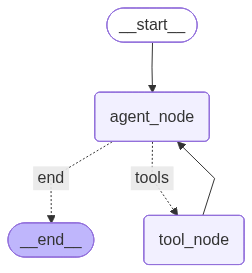

In [53]:
display(Image(vat_agent_graph.get_graph().draw_mermaid_png()))

In [61]:
result = vat_agent_graph.invoke({ "query": "what is the gross price for a 10k€ item?"})

In [62]:
result

{'query': 'what is the gross price for a 10k€ item?',
 'messages': [AIMessage(content=[{'arguments': '{"amount":10000}', 'call_id': 'call_PFlyy3MIpMia6HFTFs3ViJqi', 'name': 'add_vat', 'type': 'function_call', 'id': 'fc_00e51dabd9b87e95006a4fac7055fc81a293490e41fd143df2', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_00e51dabd9b87e95006a4fac6feca481a29ad82f6e531ae8de', 'created_at': 1783606383.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_00e51dabd9b87e95006a4fac6feca481a29ad82f6e531ae8de', tool_calls=[{'name': 'add_vat', 'args': {'amount': 10000}, 'id': 'call_PFlyy3MIpMia6HFTFs3ViJqi', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 168, 'output_tokens': 20, 'total_tokens': 188, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}}),
  To